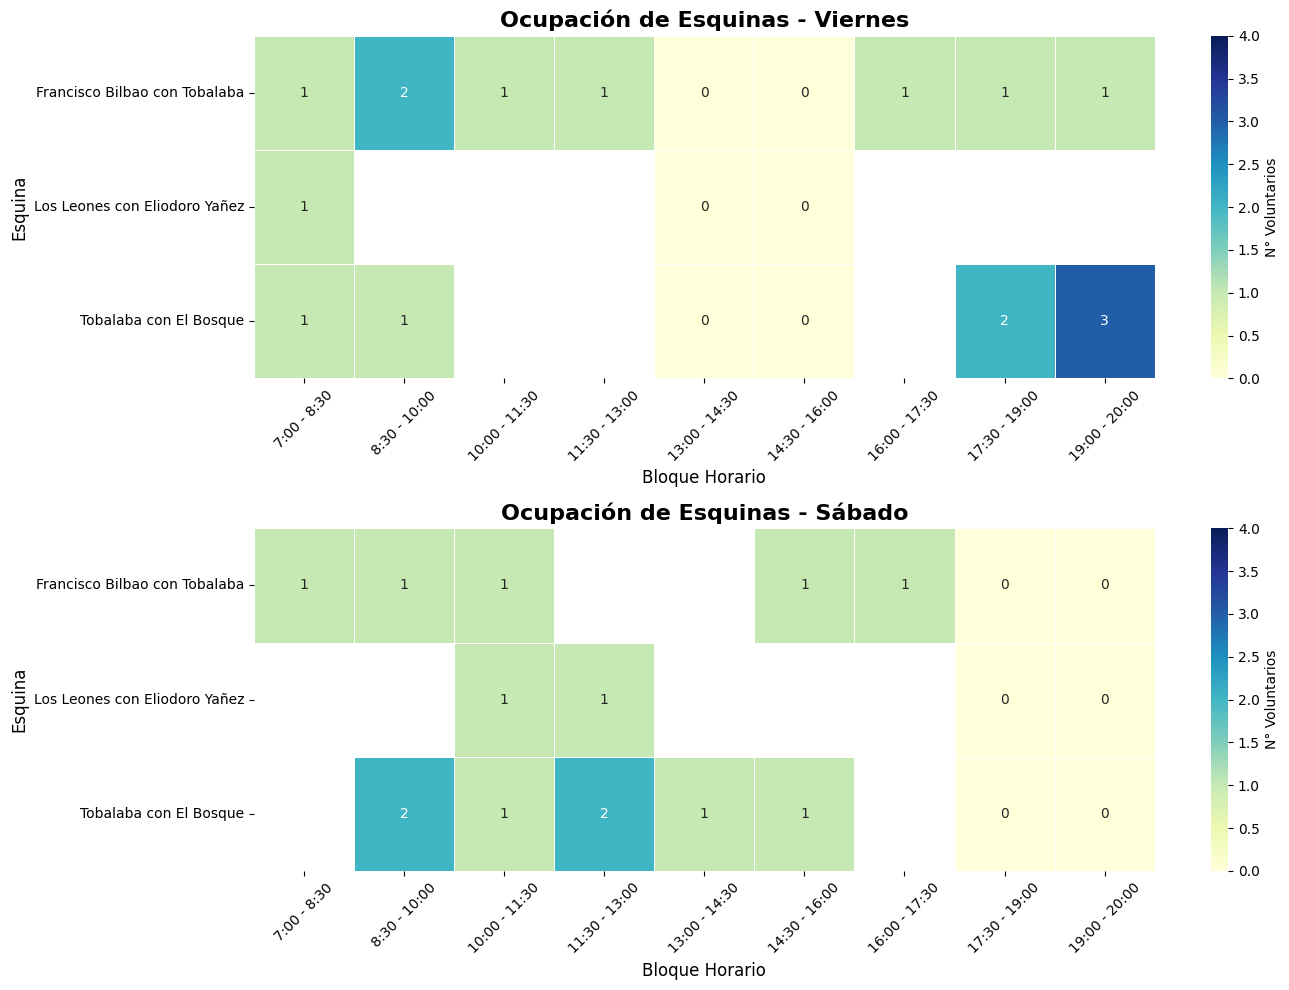

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
import re
from pathlib import Path

# Aquí debes poner los datos del CSV que compartiste
# El notebook se ejecuta desde src/, y el CSV está en data/
project_root = Path.cwd().parent
csv_file = project_root / "data" / "assignments.csv"
csv_path = str(csv_file)
df = pd.read_csv(csv_file)

# Limpieza de espacios y saltos extraños (como los \xa0 que a veces deja Google Sheets)
df['slot'] = df['slot'].apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
df['slot'] = df['slot'].str.replace(r'\s*-\s*', ' - ', regex=True)

# Lista con el orden estricto de los horarios
slots_order = [
    "7:00 - 8:30", "8:30 - 10:00", "10:00 - 11:30", "11:30 - 13:00",
    "13:00 - 14:30", "14:30 - 16:00", "16:00 - 17:30", "17:30 - 19:00", "19:00 - 20:00"
]

# Agrupar para contar la cantidad de voluntarios en cada cruce
counts = df.groupby(['date', 'location', 'slot']).size().reset_index(name='volunteers')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, date in enumerate(['Viernes', 'Sábado']):
    # Pivotear la tabla para convertirla en matriz
    pivot = counts[counts['date'] == date].pivot(index='location', columns='slot', values='volunteers')
    
    # Asegurar columnas faltantes
    for col in slots_order:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot.reindex(columns=slots_order, fill_value=0)
    
    # Dibujar el mapa de calor
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", vmin=0, vmax=4, ax=axes[i], 
                linewidths=.5, cbar_kws={'label': 'N° Voluntarios'})
    axes[i].set_title(f'Ocupación de Esquinas - {date}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Bloque Horario', fontsize=12)
    axes[i].set_ylabel('Esquina', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cronograma_visualizacion.png', dpi=300)

In [10]:
df.head(30)

,volunteer,date,slot,location,correo,telefono
0,Jose Pedro Cordeu,Sábado,10:00 - 11:30,Francisco Bilbao con Tobalaba,jpcordeu@uc.cl,+56951071233
1,Felipe Beltran,Sábado,10:00 - 11:30,Los Leones con Eliodoro Yañez,fbeltrang@uc.cl,+56952525679
2,Natalia Lorena Torres Guarachi,Sábado,10:00 - 11:30,Tobalaba con El Bosque,nltorresg@uc.cl,+56984482734
3,Felipe Beltran,Sábado,11:30 - 13:00,Los Leones con Eliodoro Yañez,fbeltrang@uc.cl,+56952525679
4,Fernanda Godoy,Sábado,11:30 - 13:00,Tobalaba con El Bosque,fgoda@uc.cl,+56950097747
5,Natalia Lorena Torres Guarachi,Sábado,11:30 - 13:00,Tobalaba con El Bosque,nltorresg@uc.cl,+56984482734
6,Paz,Sábado,13:00 - 14:30,Tobalaba con El Bosque,paz.arenas@uc.cl,+56942797209
7,Chamo,Sábado,14:30 - 16:00,Francisco Bilbao con Tobalaba,andresjsaab2001@gmail.com,69096909
8,Paz,Sábado,14:30 - 16:00,Tobalaba con El Bosque,paz.arenas@uc.cl,+56942797209
9,Chamo,Sábado,16:00 - 17:30,Francisco Bilbao con Tobalaba,andresjsaab2001@gmail.com,69096909


In [2]:
project_root = Path.cwd().parent
csv_file = project_root / "data" / "respuestas.csv"
csv_path = str(csv_file)
respuestas = pd.read_csv(csv_path, sep=";")

In [3]:
respuestas.head

<bound method NDFrame.head of          Marca temporal Dirección de correo electrónico  \
0     6-9-2025 11:33:51          jos.nordenflycht@uc.cl   
1     6-9-2025 13:13:23    simonvaldesmenares@gmail.com   
2     6-9-2025 13:16:23        trinidv@estudiante.uc.cl   
3     6-9-2025 13:17:19         blankirolando@gmail.com   
4     6-9-2025 13:19:17       tfortuno@estudiante.uc.cl   
..                  ...                             ...   
112  6-13-2025 16:36:39             antonia.leiva@uc.cl   
113  6-13-2025 18:15:11               sofiarojasu@uc.cl   
114  6-13-2025 18:55:02        mardones.ivian@gmail.com   
115  6-13-2025 20:13:20         mariajosegonzalez@uc.cl   
116  6-13-2025 20:22:12                 hector.nm@uc.cl   

                        Nombre completo  \
0               José Tomás Nordenflycht   
1                  Simon Valdes Menares   
2                         Trinidad Diaz   
3                        Blanka Rolando   
4                María Trinidad Fortuño   
.. 

In [4]:
respuestas.groupby(by=["¿Qué harías si tuvieses un millón de pesos? (importantísimo)"]).count()["Nombre completo"]

¿Qué harías si tuvieses un millón de pesos? (importantísimo)
Invertir en la bolsa de valores📈     7
Irse de viaje🛫                      14
Regalarselos a TDI💛🖤                 1
Regalárselos a TDI💛🖤                51
Todo al rojo🤞🔴                      41
Name: Nombre completo, dtype: int64